# III: Reduction and Background
# Notebook with some basic data reduction and analysis with python

## First, import necessary libraries

In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import fits
import os

## Let's open fits files

In [3]:
dir = './sheliak' # directory where fits files are found
sheliak_files = []
#process all the directories in sheliak
filters = ['black', 'blue', 'green', 'red']
for dirs in filters:
    print(dirs)
    for file in os.listdir(dir+'/'+dirs):
        if file.endswith(".fits"):
            sheliak_files.append((dir+'/'+dirs+'/'+file, dirs))

sheliak_science = []
for file, dirs in sheliak_files:
    image = fits.getdata(file)
    sheliak_science.append((image, dirs))

#multiple master flats for each filter

file2= './' + 'bias/' +'master_bias.fits' #file names
master_bias = fits.getdata(file2)  # data matrices
master_flats = {}
for dirs in os.listdir('./flats'):
    file3 = './flats/' + dirs + '/master_flat_' + dirs + '.fits'  # file names
    master_flat = fits.getdata(file3)  # data matrices
    #make a name for each master flat
    master_flats[dirs] = master_flat


black
blue
green
red


## Reduce the science file

In [4]:
#we can delete because in the telescope we used there are not masks and so we can ignore this
sheliak_science_calibrated = []
for science, dirs in sheliak_science: 
  # Find the master flat matching the current dirs
  master_flat = master_flats[dirs]
  science_calibrated = (science - master_bias) / master_flat
  # This example needs a mask!
  # mask = np.zeros(np.shape(science_calibrated))
  # for i in range(len(science_calibrated)):
  #   for j in range(len(science_calibrated[i])):
  #     if master_flat[i][j] < 0.2:
  #       science_calibrated[i][j] = 0
  #       mask[i][j] = 1
  # mask = mask.astype(bool)
  sheliak_science_calibrated.append((science_calibrated, dirs))


## Plot fits files

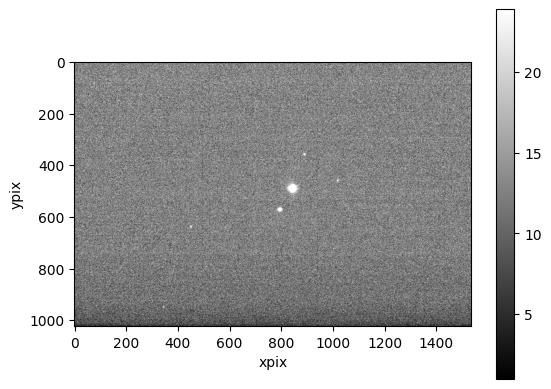

In [6]:
#one plot to try to see the first one only
for science_calibrated, dirs in sheliak_science_calibrated:
    lo,up = np.percentile(science_calibrated,5),np.percentile(science_calibrated,95)
    plt.figure()
    plt.imshow(science_calibrated,cmap='gray',clim=(lo,up))
    plt.colorbar()
    plt.xlabel('xpix')
    plt.ylabel('ypix')
    break
    

Processing filter: black
Shifted black image 0: dx=-2, dy=-2
Shifted black image 1: dx=0, dy=-1
Shifted black image 2: dx=-1, dy=0
Shifted black image 3: dx=-1, dy=-2
Shifted black image 4: dx=0, dy=1
Shifted black image 5: dx=0, dy=0
Shifted black image 6: dx=-3, dy=-6
Shifted black image 7: dx=-2, dy=1
Shifted black image 8: dx=0, dy=-1
Shifted black image 9: dx=-1, dy=0
Processing filter: blue
Shifted blue image 0: dx=0, dy=0
Shifted blue image 1: dx=0, dy=0
Shifted blue image 2: dx=1, dy=1
Shifted blue image 3: dx=0, dy=1
Shifted blue image 4: dx=0, dy=0
Shifted blue image 5: dx=0, dy=0
Shifted blue image 6: dx=1, dy=1
Shifted blue image 7: dx=1, dy=1
Shifted blue image 8: dx=-2, dy=0
Shifted blue image 9: dx=1, dy=2
Processing filter: green
Shifted green image 0: dx=1, dy=-5
Shifted green image 1: dx=4, dy=0
Shifted green image 2: dx=4, dy=0
Shifted green image 3: dx=1, dy=-4
Shifted green image 4: dx=2, dy=-1
Shifted green image 5: dx=0, dy=0
Shifted green image 6: dx=1, dy=-2
Sh

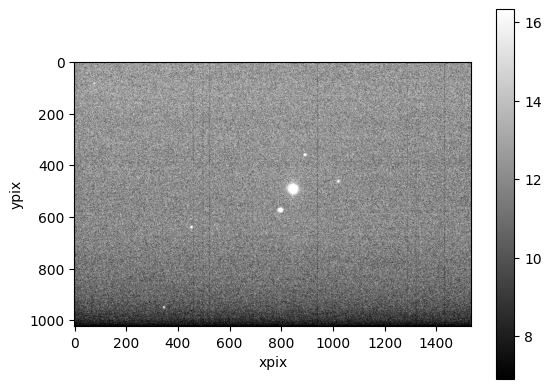

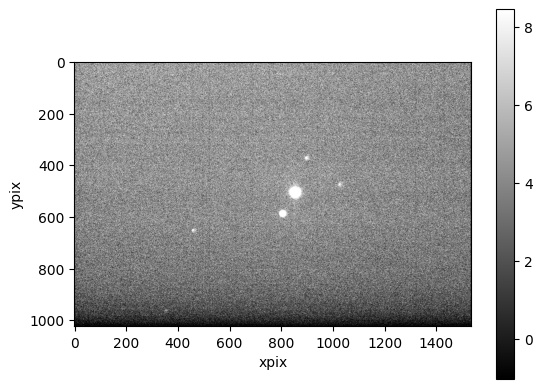

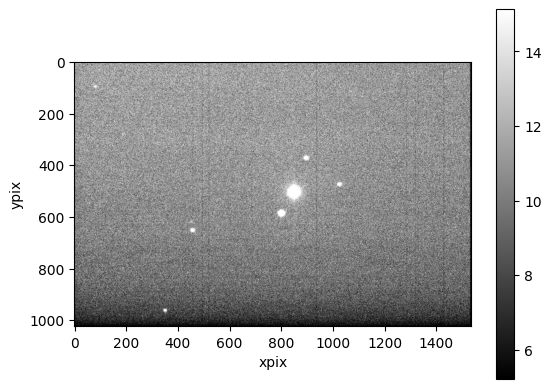

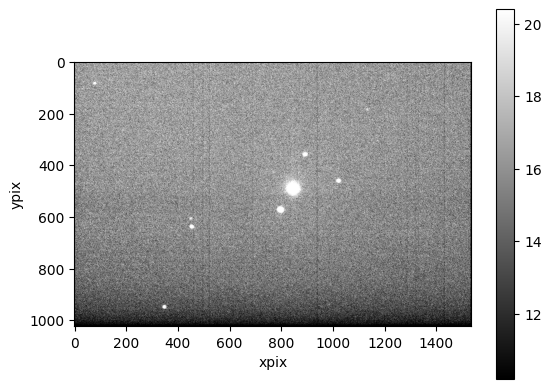

In [9]:
from scipy.ndimage import shift
from photutils.centroids import centroid_2dg

# Directory to save shifted and stacked images
output_dir = './sheliak/shifted_stacked/'
os.makedirs(output_dir, exist_ok=True)

# Approximate star position for alignment (x, y)
ref_positions = {
    'blue': [857, 508],
    'red': [850, 492],
    'black': [848, 494],
    'green': [856, 505]
}

# Organize images by filter
from collections import defaultdict
images_by_filter = defaultdict(list)
for img, filt in sheliak_science_calibrated:
    images_by_filter[filt].append(img)

stacked_images = {}
# Process each filter separately
for filt, img_list in images_by_filter.items():
    print(f"Processing filter: {filt}")
    
    pos = ref_positions[filt]

    # Pick the first image as reference
    ref_image = img_list[5]
    subref = ref_image[pos[1]-20:pos[1]+20, pos[0]-20:pos[0]+20]
    ref_center = centroid_2dg(subref) + pos - [20, 20]
    
    shifted_images = []
    
    for idx, image in enumerate(img_list):
        # Extract subimage for centroiding
        subdata = image[pos[1]-20:pos[1]+20, pos[0]-20:pos[0]+20]
        center = centroid_2dg(subdata) + pos - [20, 20]
        
        # Compute integer pixel shift
        dy = int(np.round(center[1] - ref_center[1]))
        dx = int(np.round(center[0] - ref_center[0]))
        
        # Shift the full image
        shifted = shift(image, (-dy, -dx))
        shifted_images.append(shifted)
        
        print(f"Shifted {filt} image {idx}: dx={dx}, dy={dy}")
    
    # Stack shifted images (median)
    stacked = np.median(np.array(shifted_images), axis=0)
    stacked_images[filt] = stacked
    
    # Save the stacked image
    out_file = os.path.join(output_dir, f"{filt}_stacked.fits")

    lo,up = np.percentile(stacked,5),np.percentile(stacked,95)
    plt.figure()
    plt.imshow(stacked,cmap='gray',clim=(lo,up))
    plt.colorbar()
    plt.xlabel('xpix')
    plt.ylabel('ypix')
    fits.writeto(out_file, stacked, overwrite=True)

### 1st Method for background subtraction

In [9]:
bgsub_dir = './sheliak/bgsub_stacked/'
os.makedirs(bgsub_dir, exist_ok=True)
filters = ['blue', 'green', 'red']

# Example coordinates for empty sky region (adjust per your image)
# You can pick different regions for each filter if needed
sky_regions = {
    
    'blue':  [slice(720,760), slice(480,520)],
    'green': [slice(760,800), slice(420,480)],
    'red':   [slice(760,800), slice(420,480)]
}

bgsub_images = {}  # store the background-subtracted images
for filt in filters:
    image = stacked_images[filt]
    
    # Select empty sky region
    yslice, xslice = sky_regions[filt]
    sky_region = image[yslice, xslice]
    
    # Compute median background
    sky_bg = np.median(sky_region)
    
    # Subtract background
    image_bgsub = image - sky_bg

    bgsub_images[filt] = image_bgsub  # store in dictionary
    
    # Save background-subtracted image
    out_file = os.path.join(bgsub_dir, f"{filt}_stacked_bgsub.fits")
    fits.writeto(out_file, image_bgsub, overwrite=True)
    
    print(f"{filt} background subtracted: median sky = {sky_bg}")

blue background subtracted: median sky = 3.9292034849775606
green background subtracted: median sky = 9.856984186315248
red background subtracted: median sky = 15.03820129448089


### 2nd Method for Background Subtraction

blue background-subtracted image saved. Median B2D = 3.94
green background-subtracted image saved. Median B2D = 10.47
red background-subtracted image saved. Median B2D = 15.66
black background-subtracted image saved. Median B2D = 11.97


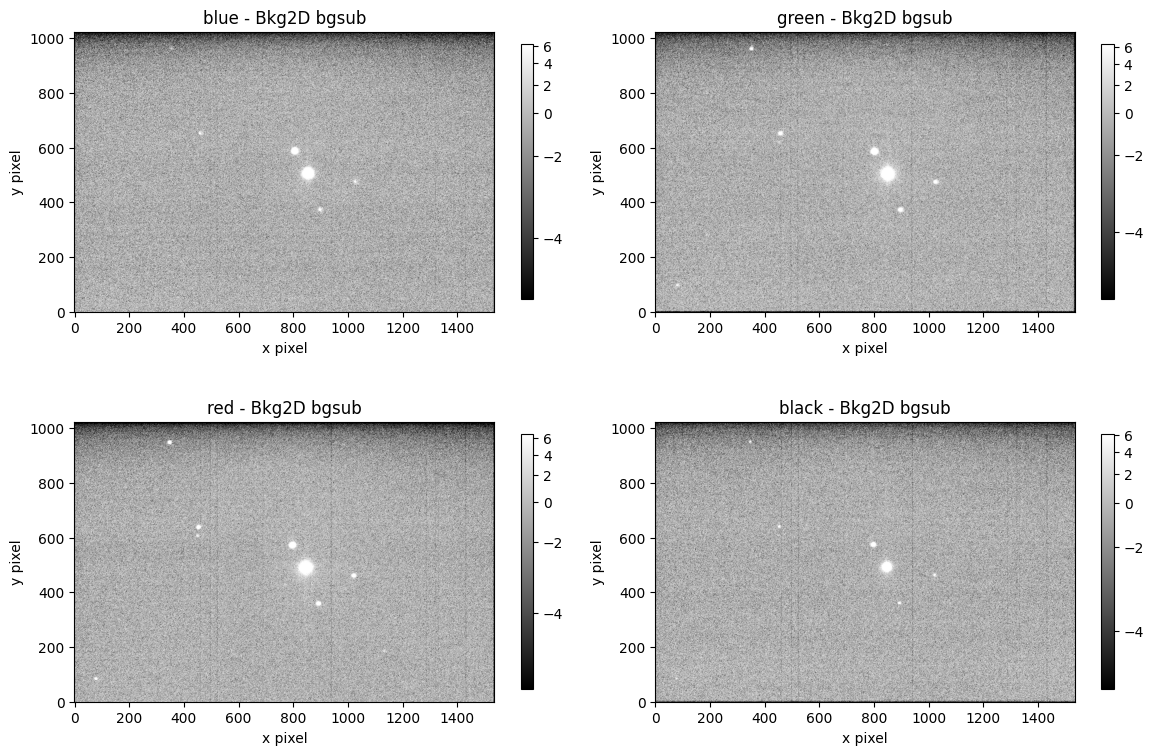

In [8]:
from astropy.stats import SigmaClip
from photutils.background import MedianBackground, Background2D
from astropy.visualization import simple_norm

# Directory to save background-subtracted images
bgsub_dir = './sheliak/bgsub_stacked/'
os.makedirs(bgsub_dir, exist_ok=True)

filters = ['blue', 'green', 'red', 'black']

bkg2d_bgsub = {}

for filt in filters:
    image = stacked_images[filt]
    
    # Compute 2D background
    sigma_clip = SigmaClip(sigma=3.0)
    bkg_estimator = MedianBackground()
    bkg = Background2D(image, box_size=(250,250), filter_size=(3,3),
                       sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
    
    # Subtract background
    image_bgsub = image - bkg.background
    bkg2d_bgsub[filt] = image_bgsub
    
    # Save background-subtracted image
    out_file = os.path.join(bgsub_dir, f"{filt}_stacked_bgsub.fits")
    fits.writeto(out_file, image_bgsub, overwrite=True)
    
    print(f"{filt} background-subtracted image saved. Median B2D = {bkg.background_median:.2f}")

# Plot the background-subtracted images
plt.figure(figsize=(12, 8))
for i, filt in enumerate(filters, 1):
    norm = simple_norm(bkg2d_bgsub[filt], 'asinh', min_percent=5, max_percent=99)
    plt.subplot(2, 2, i)
    plt.imshow(bkg2d_bgsub[filt], cmap='gray', origin='lower', norm=norm)
    plt.title(f"{filt} - Bkg2D bgsub")
    plt.xlabel('x pixel')
    plt.ylabel('y pixel')
    plt.colorbar(shrink=0.7)

plt.tight_layout()
plt.show()